
# Introduction

In this project, we will see how to train a logistic regression model. This is intended as an introduction to logistic regression. However, we will not go through the mathematical intuition of the model. 

We will be working with the Breast Cancer dataset, which contains some very detailed measurements of cells. Along with each observation of measurements, we have the diagnosis of the cell (malignant or not). Our goal is to train a model that will be able to predict whether or not a given cell is malignant given only its measurements.

In [9]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Data collection
Let's start exploring the dataset and get a feel of what it represents. We can, for example, see that all the variables in our dataset –except the ID and the diagnosis– are already of type float64, which means that they are numerical. This is great for our intitial intuition of using a logistic regression model. This is because the logistic regression model takes numerical values as input and outputs a binary classification value (yes/no value).

In [10]:
df = pd.read_csv("breast_cancer.csv")
df.head()

# print(df['radius_mean']) # this way I can access each colum

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## EDA

In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [12]:
print(df.describe())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

# Data Preprocessing and Feature Engg

## Clean the data

**By using a heatmap, we can easily visualize the presence of NAs** in the dataset and address them accordingly. In this example, the dataset come with an entire column of NAs. We will drop it, along with the ID column (which is useless for our purposes) and continue with our analysis. 

We will also be converting our target variable into 1s and 0s in order to train the model.

Other than that, the dataset seems to be rather clean, so we will not need any further cleaning.

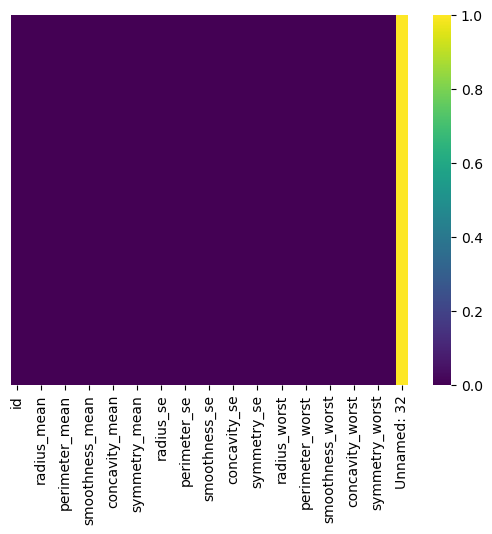

In [13]:
# visualize NAs in heatmap
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.show()

#### We see that entire column Unnamed: 32 is empty


In [14]:
# drop id and empty column
df.drop(['Unnamed: 32', "id"], axis=1, inplace=True)

In [15]:
# check missing values
print(f"Missing values: \n{df.isnull().sum()}")

Missing values: 
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [16]:
# turn target variable into 1s and 0s
df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})
print(df.head(4))

   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          17.33           184.60   
1         0.1812  ...         24.99          23.41           158.80   
2         0.2069  ...         23.57          25.53

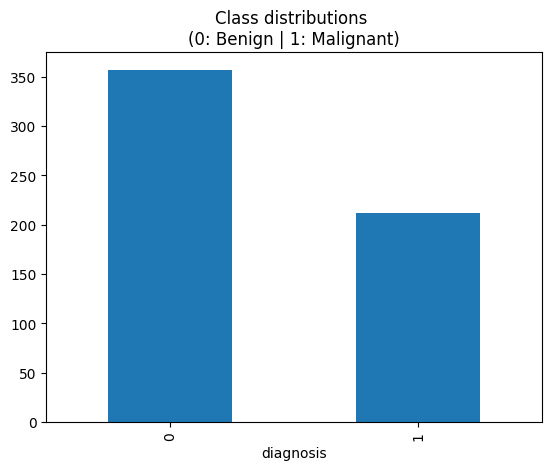

In [46]:
# turn the target variable into categorical data
df['diagnosis'] = df['diagnosis'].astype('category',copy=False)
plot = df['diagnosis'].value_counts().plot(kind='bar', title="Class distributions \n(0: Benign | 1: Malignant)")
fig = plot.get_figure()

# Logistic Regression

Once our dataset is clean that that we know that our variables are reliable, we can proceed to train our model. The first thing to do is to do is to separate the target variable (here called "y") and the predictors (here called "X"). Note that we use an uppercase X as convention in order to mymic the mathematical language. In mathematics, an uppercase symbol represents that the variable is multidimensional (a matrix).

In [18]:
# Prepare the model
# X = df(['radius_mean','texture_mean', ...and so on]) # takes a long time
X = df.drop(["diagnosis"], axis=1) # our predictors
y = df["diagnosis"] # our target variable

## Normalize the data

You might be tempted to use this data to perform the train-test split directly. But wait! The data is not yet normalized. This can be a problem, because the units of our variables are not necessarily in the same units. Also, there might be some outliers that could cause our model to perform badly. 

What we do in these cases is normalize the data before feeding it into our model. This will improve the performance of our machine learning algorithm. 

In [19]:
from sklearn.preprocessing import StandardScaler

# Create a scaler object
scaler = StandardScaler()

# Fit the scaler to the data and transform the data
X_scaled = scaler.fit_transform(X)

# X_scaled is now a numpy array with normalized data
# print(X[:4])
# print(X_scaled[:4])

We then split the dataset into a training set and a testing set. Both have the same variables (columns), but different observations (rows). To do this, we use a very conveninent Scikit-Learn function called `train_test_split`. This function takes our predictors and our target variable and splits them into a testing set and a training set randomly. It returns 4 values:

- The predictors of our training set. We store this in a python variable that we call `X_train`.
- The targets of our training set. We will store them in a python variable that we call `y_train`. 
- The predictors of our testing set. We will store them in a python variable that we call `X_test`.
- The targets of our testing set. We will store them in a python variable that we call `y_test`. 

In them, each observation (row) in `X` corresponds to the target value in `y`.

Other parameters that our function `train_test_split` takes are `test_size` and `random_state`:
- `train_test_split` sets the size of our `X_test` and its `y_test`. 
- `random_state`, which is an arbitrary integer that will allow us to replicate the split if we ever need to perform the exact random split again. We usually choose 42 because it is the answer to everything.

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=42)

In [21]:
print(X_train.shape)
print(X_test.shape)
print("#################")
print(f'X_train: {X_train[:5]}')

(398, 30)
(171, 30)
#################
X_train: [[-0.10999635 -0.32105347 -0.15854246 -0.19877178 -1.20413929 -0.76906969
  -0.75316413 -0.91901756 -1.23627745 -0.99198401 -0.56004854 -0.83360652
  -0.6401039  -0.415108   -1.40104977 -0.53419998 -0.46730568 -0.96808952
  -0.87809748 -0.68800283 -0.19241898 -0.52390482 -0.29997951 -0.27191944
  -1.5455919  -0.45716209 -0.55549797 -0.82857392 -0.89100191 -0.76506065]
 [-0.2150816  -0.67476767 -0.24174666 -0.28836101 -1.7941008  -0.58922015
  -0.09892458 -0.53958808 -1.42247556 -0.64750622 -0.87080152 -0.13943855
  -0.81336461 -0.56493964 -0.37400813  0.40362649  0.58609294 -0.22971112
  -1.02460247  0.10632499 -0.41606811 -0.47668012 -0.45486587 -0.43681165
  -1.30931644 -0.00741131  0.28119013 -0.37801891 -1.37957166 -0.42480753]
 [ 0.15981713 -1.23559085  0.25747857  0.00344391  0.47963507  1.50207561
   0.70559797  0.3632013   1.00175085  1.596561    0.50899947  0.53368304
   0.95488473  0.20049984  0.97838003  1.506886    0.69252699  

In [22]:
from sklearn.linear_model import LogisticRegression

# Create logistic regression model
model = LogisticRegression()

# Train the model on the training data
model.fit(X_train, y_train)

############### Predict the target variable on the test data and also its actual value
y_pred = model.predict(X_test)
print(y_pred)
print("################")
print(list(y_test))


########### Convert predictions and true values to DataFrame
results_df = pd.DataFrame({
    'Actual': list(y_test),
    'Predicted': y_pred
})
print(results_df)

[0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1 1 1 0 0 0 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1
 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0]
################
[0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0]
     Actual  Predicted
0         0          0
1         1          1
2         1          1
3         0          0
4     

## Evaluate the model

In this notebook, we have trained a logistic regression model to predict the target variable using a dataset of input features. As you can see here, after training the model on the training set and evaluating its performance on the test set, we achieved a final accuracy of 0.98. This is a strong performance and indicates that the model is able to make accurate predictions on new, unseen data. 

However, it's important to note that accuracy is just one measure of a model's performance, and it may not be the most appropriate measure for all problems. Depending on the problem and the specific requirements of the application, other metrics such as precision, recall, or F1 score may be more relevant. In the second cell, we use the `classification_report` function from `Scikit-learn` to calculate those measures. 

In [12]:
from sklearn.metrics import accuracy_score

# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.98


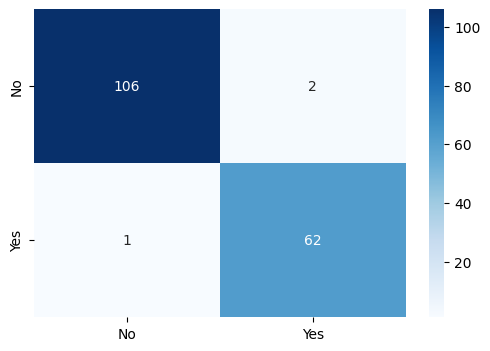

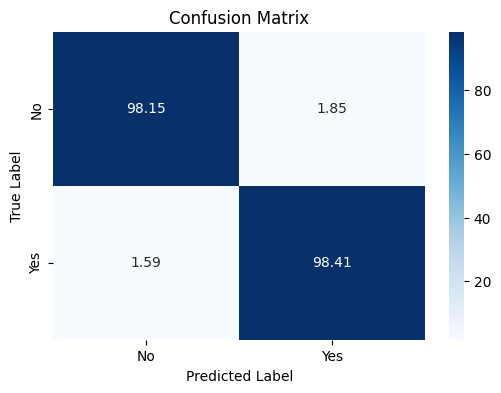

In [13]:
# Now lets display CM with actual + percentage values
from sklearn.metrics import confusion_matrix

# Assuming these are your test labels and predictions
y_pred = model.predict(X_test)  # Predicted labels
cm = confusion_matrix(y_test, y_pred)  # Compute confusion matrix

# Normalize the confusion matrix (convert to percentages)
cm_percentage = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100  # Row-wise normalization

# Plot the confusion matrix using seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])

# Labels and title
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### Thats great

In [14]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           B       0.99      0.98      0.99       108
           M       0.97      0.98      0.98        63

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



- High Precision (~0.85): Few false positives (incorrect positive predictions).
- High Recall (~0.90): Model captures most actual positives, missing very few.
- High F1-score (~0.87): Good balance between precision & recall.
- Accuracy (0.83): 83% of total predictions were correct.
- Macro vs. Weighted Avg:
   1. If classes are balanced, both values are similar.
   2. If imbalance exists, weighted avg is more meaningful.

# Conclusion

We have finished our analysis. We have used the data from the open dataset Breast Cancer in order to build a model that will predict if a given cell is malicious or not given certain measurements of its nucleus. This model, now that it is trained, can, evidently, be extremely useful to perform punctual analysis on given cells for a hospital.

However, since the model is easily callable in a python function to make predictions, this kind of model can easily be added to a server technology such as Flask and serve a front-end application that doctors can use. For example, we could build an interface where a doctor inputs some measurements that she has performed and the model would output if the cell is malicious or not. Or maybe, a more realistic use of this model could be to connect the backend application to a machine that takes a sample of tissue, measures all the cells and the performs a diagnosis. 

By using python, the API of such an application would extremely minimalist, and all we did to save the lives of people was train a logistic regression model on the hospital's data.